In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from google.colab import files

uploaded = files.upload()  # upload: baseline_features_v3_segment_split_train_val_test.npz

Saving baseline_features_v3_segment_split_train_val_test.npz to baseline_features_v3_segment_split_train_val_test.npz


In [ ]:
# Load dataset
DATA_PATH = "baseline_features_v3_segment_split_train_val_test.npz"  # must match uploaded filename
d = np.load(DATA_PATH, allow_pickle=True)

X_train = d["X_train"]
y_train = d["y_train"]
X_val   = d["X_val"]
y_val   = d["y_val"]
X_test  = d["X_test"]
y_test  = d["y_test"]
modes   = list(d["modes"])

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Modes:", modes)

# string -> int labels
mode_to_idx = {m:i for i,m in enumerate(modes)}
y_train_i = np.array([mode_to_idx[v] for v in y_train], dtype=np.int64)
y_val_i   = np.array([mode_to_idx[v] for v in y_val],   dtype=np.int64)
y_test_i  = np.array([mode_to_idx[v] for v in y_test],  dtype=np.int64)

# Add channel dim for Conv2D
X_train = X_train[..., np.newaxis].astype(np.float32)
X_val   = X_val[..., np.newaxis].astype(np.float32)
X_test  = X_test[..., np.newaxis].astype(np.float32)

print("After expand dims:", X_train.shape, X_val.shape, X_test.shape)

Shapes:
X_train: (580, 125, 7) y_train: (580,)
X_val  : (1649, 125, 7) y_val  : (1649,)
X_test : (715, 125, 7) y_test : (715,)
Modes: ['train', 'subway', 'car', 'bus', 'walk']
After expand dims: (580, 125, 7, 1) (1649, 125, 7, 1) (715, 125, 7, 1)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(len(modes))
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_i)
class_weight = {i: float(w) for i, w in zip(classes, cw)}
print("class_weight:", class_weight)

class_weight: {np.int64(0): 1.0, np.int64(1): 1.0, np.int64(2): 1.0, np.int64(3): 1.0, np.int64(4): 1.0}


In [ ]:
def build_bn_model(input_shape, n_classes, dense_units=32, dropout=0.3):
    inp = tf.keras.layers.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(16, (5,1), padding="same", use_bias=False)(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D((2,1))(x)

    x = tf.keras.layers.Conv2D(32, (5,1), padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D((2,1))(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(n_classes, activation="softmax")(x)

    model = tf.keras.Model(inp, out)
    return model

model = build_bn_model(
    input_shape=(X_train.shape[1], X_train.shape[2], 1),
    n_classes=len(modes),
    dense_units=32,
    dropout=0.3
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 125, 7, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 125, 7, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 125, 7, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 125, 7, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 7, 32)      │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 7, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 62, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       222,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,237 (879.83 KB)

 Trainable params: 225,141 (879.46 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True
    )
]

hist = model.fit(
    X_train, y_train_i,
    validation_data=(X_val, y_val_i),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.6523 - loss: 1.0043 - val_accuracy: 0.7429 - val_loss: 2.5447
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9775 - loss: 0.0890 - val_accuracy: 0.7429 - val_loss: 4.4238
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9817 - loss: 0.0512 - val_accuracy: 0.7429 - val_loss: 6.1677
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9708 - loss: 0.0927 - val_accuracy: 0.7429 - val_loss: 4.4816
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9894 - loss: 0.0488 - val_accuracy: 0.7429 - val_loss: 6.0935
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9895 - loss: 0.0337 - val_accuracy: 0.7429 - val_loss: 7.4801
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9957 - loss: 0.0140 - val_accuracy: 0.7429 - val_loss: 9.5480


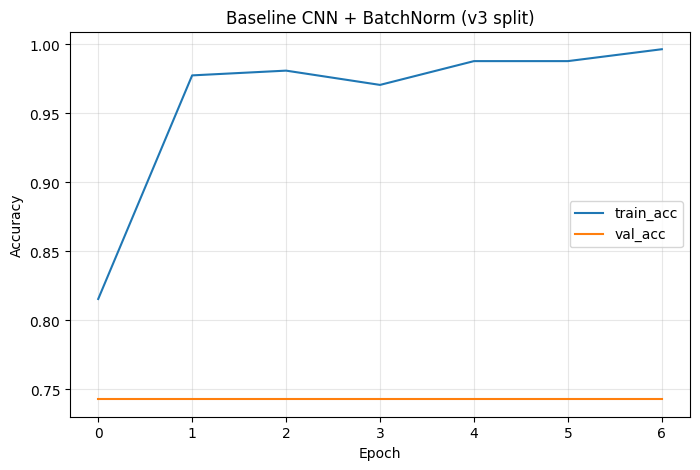

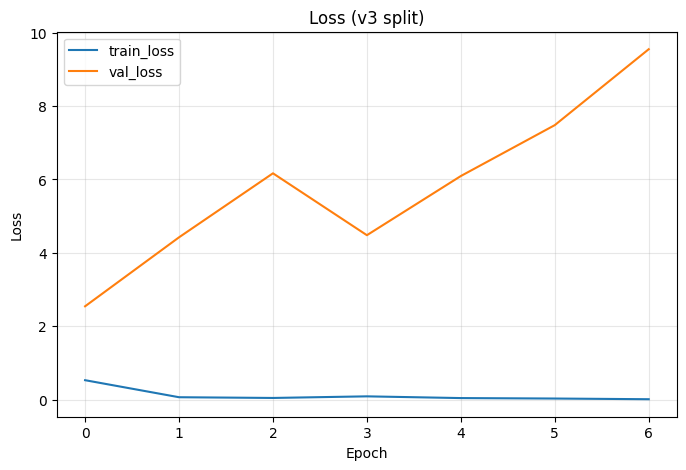

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hist.history["accuracy"], label="train_acc")
plt.plot(hist.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN + BatchNorm (v3 split)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(hist.history["loss"], label="train_loss")
plt.plot(hist.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss (v3 split)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

TEST accuracy: 0.8573


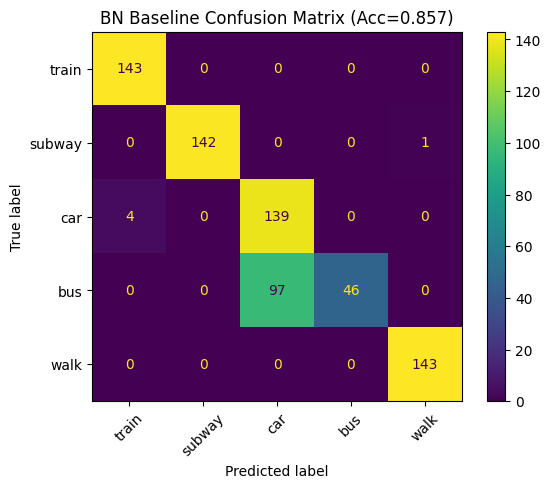


Classification report:
              precision    recall  f1-score   support

       train      0.973     1.000     0.986       143
      subway      1.000     0.993     0.996       143
         car      0.589     0.972     0.734       143
         bus      1.000     0.322     0.487       143
        walk      0.993     1.000     0.997       143

    accuracy                          0.857       715
   macro avg      0.911     0.857     0.840       715
weighted avg      0.911     0.857     0.840       715



In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_i, verbose=0)
print(f"TEST accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test_i, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)
disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"BN Baseline Confusion Matrix (Acc={test_acc:.3f})")
plt.show()

print("\nClassification report:")
print(classification_report(y_test_i, y_pred, target_names=modes, digits=3))